# Project 3: Sensor Anomaly Detector

Apply both K-means and Isolation Forest to the
multi-sensor dataset from Day 3. Use PCA to
create 2D visualisations. Evaluate against

known fault labels using precision and recall.
Write a function that, given a new sensor
reading as a list, returns 'NORMAL' or
'ANOMALY' using the trained Isolation Forest.

### Skills: KMeans, IsolationForest, PCA, sklearn metrics, inference function

--- Anomaly Detection Performance ---
Precision: 0.97 (How many flagged were actually faulty?)
Recall:    1.00 (How many actual faults did we catch?)

Full Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       400
     Anomaly       0.97      1.00      0.98        30

    accuracy                           1.00       430
   macro avg       0.98      1.00      0.99       430
weighted avg       1.00      1.00      1.00       430



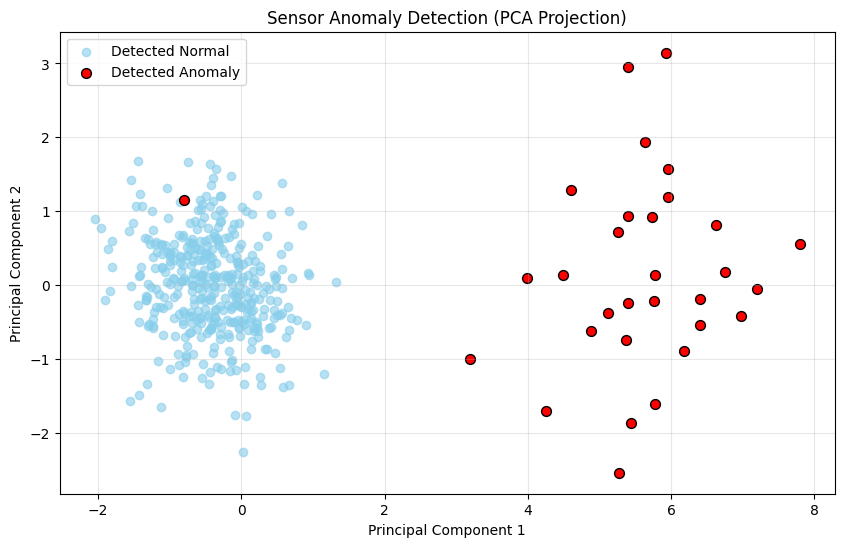

Status for typical reading: NORMAL
Status for extreme reading: ANOMALY


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import precision_score, recall_score, classification_report


# ─── MULTI-SENSOR DATA from Day 3 ──────────────────────────────────────
np.random.seed(10)
n_normal = 400
n_fault = 30
# Normal operation: 4 features
normal = np.column_stack([
np.random.normal(35, 2, n_normal), # temp
np.random.normal(220, 3, n_normal), # voltage
np.random.normal(1.3, 0.1, n_normal), # current
np.random.normal(0.03, 0.01, n_normal)# vibration
])
# Fault condition: shifted distributions
faults = np.column_stack([
np.random.normal(45, 3, n_fault), # higher temp
np.random.normal(210, 5, n_fault), # lower voltage
np.random.normal(1.8, 0.2, n_fault), # higher current
np.random.normal(0.12, 0.03, n_fault) # higher vibration
])
X_all = np.vstack([normal, faults])
true_labels = np.array([0]*n_normal + [1]*n_fault) # for evaluation only
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_all)

# --- K-Means Clustering ---
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
km_labels = kmeans.fit_predict(X_scaled)

# --- Isolation Forest Detection ---
# Contamination is set to ~7% (30 faults / 430 total)
iso_forest = IsolationForest(contamination=0.07, random_state=42)
iso_preds = iso_forest.fit_predict(X_scaled)

# Convert Isolation Forest format: 1 (normal) -> 0, -1 (anomaly) -> 1
iso_labels = np.where(iso_preds == -1, 1, 0)

# --- 3. Evaluate Metrics ---
prec = precision_score(true_labels, iso_labels)
rec = recall_score(true_labels, iso_labels)

print("--- Anomaly Detection Performance ---")
print(f"Precision: {prec:.2f} (How many flagged were actually faulty?)")
print(f"Recall:    {rec:.2f} (How many actual faults did we catch?)")
print("\nFull Report:")
print(classification_report(true_labels, iso_labels, target_names=['Normal', 'Anomaly']))

# Create 2D projection
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 6))

# Plot correctly identified normals
plt.scatter(X_pca[iso_labels == 0, 0], X_pca[iso_labels == 0, 1], 
            c='skyblue', label='Detected Normal', alpha=0.6)

# Plot detected anomalies
plt.scatter(X_pca[iso_labels == 1, 0], X_pca[iso_labels == 1, 1], 
            c='red', label='Detected Anomaly', edgecolors='black', s=50)

plt.title("Sensor Anomaly Detection (PCA Projection)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

def classify_sensor_reading(new_reading):
    """
    Classifies a sensor reading using the trained Isolation Forest.
    
    Args:
        new_reading (list): [temp, voltage, current, vibration]
        
    Returns:
        string: 'NORMAL' or 'ANOMALY'
    """
    # Convert list to 2D numpy array (1 sample, 4 features)
    reading_arr = np.array(new_reading).reshape(1, -1)
    
    # Scale the reading using the EXISTING scaler
    # Do NOT use fit_transform here; use transform only.
    scaled_reading = scaler.transform(reading_arr)
    
    # Predict (1 = Normal, -1 = Anomaly)
    prediction = iso_forest.predict(scaled_reading)
    
    return 'ANOMALY' if prediction[0] == -1 else 'NORMAL'

# --- Testing the function ---
# Example of a normal reading
print(f"Status for typical reading: {classify_sensor_reading([35.1, 220.2, 1.3, 0.02])}")

# Example of a faulty reading (high temp, high vibration)
print(f"Status for extreme reading: {classify_sensor_reading([48.5, 205.1, 2.0, 0.18])}")